# Model Training — Predicting Mental Health Score

Target: `Mental_Health_Score` (regression).
Train 10 regression models with 5-fold cross-validation, compare, pick the best, evaluate on the test set, and save it.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error


In [2]:
df = pd.read_csv('../data/processed/student_social_media_mental_health_clean.csv')
print(df.shape)
df.head()


(4998, 13)


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 1. Features & target

In [3]:
TARGET = 'Mental_Health_Score'
X = df.drop(columns=[TARGET])
y = df[TARGET]

num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
            'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ord_cols = ['Stress_Level']
cat_cols = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use']
print('Features:', X.shape[1], '| Target:', TARGET)


Features: 12 | Target: Mental_Health_Score


## 2. Preprocessing & train/test split
- Numeric → StandardScaler
- Stress_Level → ordinal (Low < Medium < High < Very High)
- Other categoricals → one-hot

In [4]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ord', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]), ord_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (3998, 12) | Test: (1000, 12)


## 3. Model zoo — cross-validated comparison

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'SVR': SVR(),
}


In [6]:
results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    results.append({'Model': name, 'CV R2 (mean)': scores.mean(), 'CV R2 (std)': scores.std()})
    print(f'{name:20s} R2: {scores.mean():.4f} +/- {scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV R2 (mean)', ascending=False).reset_index(drop=True)
results_df


Linear Regression    R2: 0.7735 +/- 0.0095


Ridge                R2: 0.7732 +/- 0.0096
Lasso                R2: 0.0320 +/- 0.0054


ElasticNet           R2: 0.4815 +/- 0.0047


KNN                  R2: 0.8530 +/- 0.0137


Decision Tree        R2: 0.8083 +/- 0.0225


Random Forest        R2: 0.8956 +/- 0.0069


Gradient Boosting    R2: 0.8319 +/- 0.0071


AdaBoost             R2: 0.7622 +/- 0.0113


SVR                  R2: 0.8456 +/- 0.0127


,Model,CV R2 (mean),CV R2 (std)
0,Random Forest,0.895578,0.006940
1,KNN,0.852988,0.013654
2,SVR,0.845566,0.012680
3,Gradient Boosting,0.831886,0.007089
4,Decision Tree,0.808336,0.022523
5,Linear Regression,0.773534,0.009547
6,Ridge,0.773155,0.009592
7,AdaBoost,0.762235,0.011329
8,ElasticNet,0.481493,0.004686
9,Lasso,0.032010,0.005438


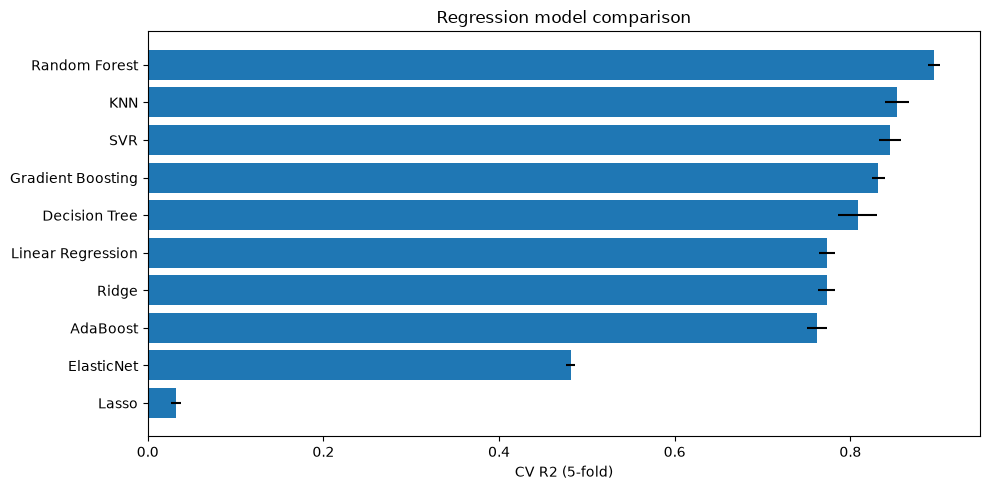

In [7]:
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['CV R2 (mean)'], xerr=results_df['CV R2 (std)'])
plt.xlabel('CV R2 (5-fold)')
plt.title('Regression model comparison')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Best model — test set evaluation

In [8]:
best_name = results_df.iloc[0]['Model']
print('Best model:', best_name)

best_pipe = Pipeline([('prep', preprocess), ('model', models[best_name])])
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'Test R2:  {r2:.4f}')
print(f'Test MAE: {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')


Best model: Random Forest


Test R2:  0.9171
Test MAE: 0.2774
Test RMSE: 0.3847


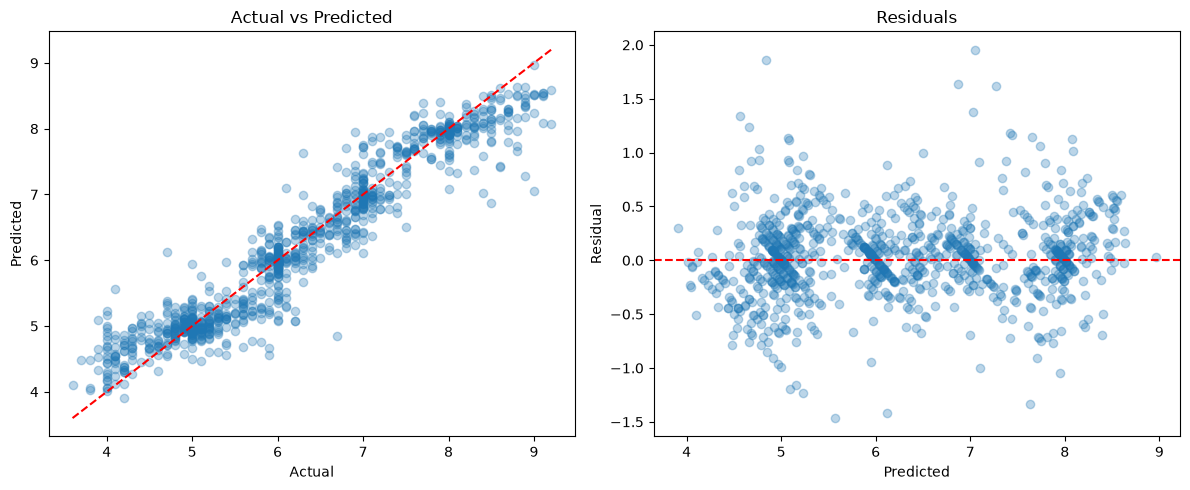

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set(xlabel='Actual', ylabel='Predicted', title='Actual vs Predicted')
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set(xlabel='Predicted', ylabel='Residual', title='Residuals')
plt.tight_layout()
plt.show()


## 5. Save the best model

In [10]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipe, '../models/best_model.joblib')
print(f'Saved {best_name} -> ../models/best_model.joblib')


Saved Random Forest -> ../models/best_model.joblib
